# A/B Testing Case Study: Facebook vs Google Ads
Problem Statement
TechMart Electronics needs to determine which advertising platform delivers better ROI for their Winter Sale 2024 campaign. With a limited budget of $2,000/day, they must choose the most cost-effective platform for future investments.
Business Context

Campaign: Winter Sale 2024 (Electronics)
Duration: 31 days (Jan 1-31, 2024)
Budget: $1,000/day per platform
Target: Tech enthusiasts aged 25-45

Goals

Primary: Determine winning platform based on ROAS
Secondary: Identify most cost-effective channel (lowest CPA)
Outcome: Optimize budget allocation for future campaigns

Success Criteria

Target ROAS: > 3:1
Target CPA: < $30
Statistical Significance: p-value < 0.05

Research Questions

Which platform delivers higher ROAS?
Is there a significant difference in conversion rates?
Which platform has better cost efficiency?
How do platforms compare over time?

Expected Outcome
Data-driven recommendation for budget allocation between Facebook and Google Ads for Q1 2024 marketing strategy.

In [229]:
#Import all libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
# Change default figure size
plt.rcParams['figure.figsize'] = (10, 6)
# Change default font size
plt.rcParams['font.size'] = 8
# Change default line width
plt.rcParams['lines.linewidth'] = 2

In [163]:
#Load and combined data

df=pd.read_csv('facebook_campaign_data.csv')
df1= pd.read_csv('google_ads_campaign_data.csv')


In [165]:
df1.head()

,date,campaign_name,platform,campaign_type,objective,audience,budget,impressions,clicks,spend,conversions,ctr,cpc,cpa,conversion_rate,roas,revenue,search_impression_share,quality_score,top_impression_rate,abs_top_impression_rate,cpp,device_desktop,device_mobile,device_tablet,age_25_34,age_35_44,age_45_54,age_55_64,gender_male,gender_female,location_tier1,location_tier2
0,2024-01-01,Winter_Sale_2024,Google Ads,Search,Conversions,Tech_Enthusiasts_25_45,1000,35288,1175,1256.24,49,3.330,1.07,25.64,4.247,5.66,7110.29,48.38,7,0.321,0.243,35.60,0.367,0.502,0.065,0.355,0.439,0.214,0.099,0.561,0.298,0.717,0.309
1,2024-01-02,Winter_Sale_2024,Google Ads,Search,Conversions,Tech_Enthusiasts_25_45,1000,37928,1513,1854.98,58,3.990,1.23,31.98,3.880,3.30,6124.21,59.05,7,0.482,0.229,48.91,0.423,0.716,0.067,0.284,0.460,0.230,0.009,0.600,0.256,0.665,0.302
2,2024-01-03,Winter_Sale_2024,Google Ads,Search,Conversions,Tech_Enthusiasts_25_45,1000,45058,1515,1827.36,66,3.363,1.21,27.69,4.381,2.86,5218.84,42.89,9,0.473,0.258,40.56,0.446,0.480,0.042,0.325,0.462,0.298,0.052,0.626,0.370,0.591,0.218
3,2024-01-04,Winter_Sale_2024,Google Ads,Search,Conversions,Tech_Enthusiasts_25_45,1000,44058,1498,1768.38,65,3.401,1.18,27.21,4.380,3.20,5654.77,77.87,7,0.511,0.204,40.14,0.470,0.658,0.058,0.394,0.361,0.188,0.014,0.725,0.383,0.694,0.328
4,2024-01-05,Winter_Sale_2024,Google Ads,Search,Conversions,Tech_Enthusiasts_25_45,1000,28247,1249,1593.53,48,4.423,1.28,33.20,3.877,2.98,4747.37,72.26,8,0.485,0.263,56.41,0.309,0.443,0.088,0.309,0.405,0.245,0.066,0.777,0.376,0.641,0.287


In [167]:
df.head()

,date,campaign_name,platform,campaign_type,objective,audience,budget,impressions,clicks,spend,conversions,ctr,cpc,cpa,conversion_rate,roas,revenue,post_engagement,video_views,page_likes,frequency,reach,cpp,device_desktop,device_mobile,age_25_34,age_35_44,age_45_54,gender_male,gender_female
0,2024-01-01,Winter_Sale_2024,Facebook,Conversion,Purchase,Tech_Enthusiasts_25_45,1000,53973,949,898.85,54,1.759,0.95,16.65,5.718,5.80,5211.62,1286,7716,150,1.96,23852,16.65,0.227,0.727,0.362,0.354,0.114,0.572,0.349
1,2024-01-02,Winter_Sale_2024,Facebook,Conversion,Purchase,Tech_Enthusiasts_25_45,1000,52513,802,511.80,45,1.528,0.64,11.37,5.673,6.76,3457.54,1253,7983,67,2.13,29927,9.75,0.269,0.720,0.335,0.420,0.293,0.599,0.347
2,2024-01-03,Winter_Sale_2024,Facebook,Conversion,Purchase,Tech_Enthusiasts_25_45,1000,56580,811,714.76,23,1.434,0.88,31.08,2.932,2.82,2014.12,1038,8821,134,2.07,28154,12.63,0.176,0.714,0.327,0.503,0.217,0.512,0.416
3,2024-01-04,Winter_Sale_2024,Facebook,Conversion,Purchase,Tech_Enthusiasts_25_45,1000,46919,749,705.37,39,1.597,0.94,18.09,5.325,4.97,3508.79,1391,5856,86,2.39,23984,15.03,0.241,0.695,0.290,0.491,0.268,0.596,0.450
4,2024-01-05,Winter_Sale_2024,Facebook,Conversion,Purchase,Tech_Enthusiasts_25_45,1000,52893,849,767.67,48,1.606,0.90,15.99,5.730,6.09,4671.77,1312,10416,36,2.13,26311,14.51,0.255,0.651,0.339,0.468,0.274,0.574,0.360


In [169]:
df['date']=pd.to_datetime(df['date'])
df1['date']=pd.to_datetime(df1['date'])

In [173]:
df.columns

Index(['date', 'campaign_name', 'platform', 'campaign_type', 'objective',
       'audience', 'budget', 'impressions', 'clicks', 'spend', 'conversions',
       'ctr', 'cpc', 'cpa', 'conversion_rate', 'roas', 'revenue',
       'post_engagement', 'video_views', 'page_likes', 'frequency', 'reach',
       'cpp', 'device_desktop', 'device_mobile', 'age_25_34', 'age_35_44',
       'age_45_54', 'gender_male', 'gender_female'],
      dtype='object')

In [179]:
key_metrics =['date','impressions', 'clicks', 'spend', 'conversions','ctr', 'cpc', 'cpa', 'conversion_rate', 'roas', 'revenue']

In [189]:
facebook_df=df[key_metrics].copy()
facebook_df.head()

,date,impressions,clicks,spend,conversions,ctr,cpc,cpa,conversion_rate,roas,revenue
0,2024-01-01,53973,949,898.85,54,1.759,0.95,16.65,5.718,5.80,5211.62
1,2024-01-02,52513,802,511.80,45,1.528,0.64,11.37,5.673,6.76,3457.54
2,2024-01-03,56580,811,714.76,23,1.434,0.88,31.08,2.932,2.82,2014.12
3,2024-01-04,46919,749,705.37,39,1.597,0.94,18.09,5.325,4.97,3508.79
4,2024-01-05,52893,849,767.67,48,1.606,0.90,15.99,5.730,6.09,4671.77


In [191]:
google_df=df1[key_metrics].copy()
google_df.head()

,date,impressions,clicks,spend,conversions,ctr,cpc,cpa,conversion_rate,roas,revenue
0,2024-01-01,35288,1175,1256.24,49,3.330,1.07,25.64,4.247,5.66,7110.29
1,2024-01-02,37928,1513,1854.98,58,3.990,1.23,31.98,3.880,3.30,6124.21
2,2024-01-03,45058,1515,1827.36,66,3.363,1.21,27.69,4.381,2.86,5218.84
3,2024-01-04,44058,1498,1768.38,65,3.401,1.18,27.21,4.380,3.20,5654.77
4,2024-01-05,28247,1249,1593.53,48,4.423,1.28,33.20,3.877,2.98,4747.37


In [193]:
df= pd.merge(facebook_df,google_df, on='date',suffixes=('_facebook','_google'))
df.head()

,date,impressions_facebook,clicks_facebook,spend_facebook,conversions_facebook,ctr_facebook,cpc_facebook,cpa_facebook,conversion_rate_facebook,roas_facebook,revenue_facebook,impressions_google,clicks_google,spend_google,conversions_google,ctr_google,cpc_google,cpa_google,conversion_rate_google,roas_google,revenue_google
0,2024-01-01,53973,949,898.85,54,1.759,0.95,16.65,5.718,5.80,5211.62,35288,1175,1256.24,49,3.330,1.07,25.64,4.247,5.66,7110.29
1,2024-01-02,52513,802,511.80,45,1.528,0.64,11.37,5.673,6.76,3457.54,37928,1513,1854.98,58,3.990,1.23,31.98,3.880,3.30,6124.21
2,2024-01-03,56580,811,714.76,23,1.434,0.88,31.08,2.932,2.82,2014.12,45058,1515,1827.36,66,3.363,1.21,27.69,4.381,2.86,5218.84
3,2024-01-04,46919,749,705.37,39,1.597,0.94,18.09,5.325,4.97,3508.79,44058,1498,1768.38,65,3.401,1.18,27.21,4.380,3.20,5654.77
4,2024-01-05,52893,849,767.67,48,1.606,0.90,15.99,5.730,6.09,4671.77,28247,1249,1593.53,48,4.423,1.28,33.20,3.877,2.98,4747.37


In [195]:
df.isna().sum()

date                        0
impressions_facebook        0
clicks_facebook             0
spend_facebook              0
conversions_facebook        0
ctr_facebook                0
cpc_facebook                0
cpa_facebook                0
conversion_rate_facebook    0
roas_facebook               0
revenue_facebook            0
impressions_google          0
clicks_google               0
spend_google                0
conversions_google          0
ctr_google                  0
cpc_google                  0
cpa_google                  0
conversion_rate_google      0
roas_google                 0
revenue_google              0
dtype: int64

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      31 non-null     datetime64[ns]
 1   impressions_facebook      31 non-null     int64         
 2   clicks_facebook           31 non-null     int64         
 3   spend_facebook            31 non-null     float64       
 4   conversions_facebook      31 non-null     int64         
 5   ctr_facebook              31 non-null     float64       
 6   cpc_facebook              31 non-null     float64       
 7   cpa_facebook              31 non-null     float64       
 8   conversion_rate_facebook  31 non-null     float64       
 9   roas_facebook             31 non-null     float64       
 10  revenue_facebook          31 non-null     float64       
 11  impressions_google        31 non-null     int64         
 12  clicks_google           

In [199]:
df.shape

(31, 21)

In [201]:
df.dtypes

date                        datetime64[ns]
impressions_facebook                 int64
clicks_facebook                      int64
spend_facebook                     float64
conversions_facebook                 int64
ctr_facebook                       float64
cpc_facebook                       float64
cpa_facebook                       float64
conversion_rate_facebook           float64
roas_facebook                      float64
revenue_facebook                   float64
impressions_google                   int64
clicks_google                        int64
spend_google                       float64
conversions_google                   int64
ctr_google                         float64
cpc_google                         float64
cpa_google                         float64
conversion_rate_google             float64
roas_google                        float64
revenue_google                     float64
dtype: object

In [203]:
df.describe()

,date,impressions_facebook,clicks_facebook,spend_facebook,conversions_facebook,ctr_facebook,cpc_facebook,cpa_facebook,conversion_rate_facebook,roas_facebook,revenue_facebook,impressions_google,clicks_google,spend_google,conversions_google,ctr_google,cpc_google,cpa_google,conversion_rate_google,roas_google,revenue_google
count,31,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2024-01-16 00:00:00,52360.612903,921.064516,786.071935,42.741935,1.774710,0.845161,18.860968,4.682097,4.649677,3517.058065,37036.903226,1264.161290,1548.828065,46.774194,3.455677,1.222581,34.309677,3.728935,2.865161,4389.576129
min,2024-01-01 00:00:00,31292.000000,528.000000,378.860000,23.000000,1.404000,0.610000,11.370000,2.932000,2.340000,1856.760000,15544.000000,565.000000,528.610000,18.000000,2.437000,0.900000,21.130000,2.175000,1.410000,1726.290000
25%,2024-01-08 12:00:00,45474.000000,792.000000,645.595000,33.000000,1.557000,0.730000,15.195000,4.085000,3.575000,2533.670000,28622.500000,989.000000,1201.820000,35.500000,3.118500,1.135000,29.175000,3.526500,2.365000,3195.775000
50%,2024-01-16 00:00:00,52513.000000,934.000000,760.130000,42.000000,1.759000,0.860000,18.000000,4.823000,4.870000,3508.790000,37928.000000,1284.000000,1542.630000,49.000000,3.459000,1.200000,31.450000,3.783000,2.730000,4499.020000
75%,2024-01-23 12:00:00,60420.500000,1090.000000,904.130000,52.000000,1.925500,0.935000,21.750000,5.371500,5.565000,4382.245000,44761.500000,1560.500000,1842.100000,58.500000,3.734000,1.295000,37.615000,4.086000,3.215000,5797.940000
max,2024-01-31 00:00:00,77309.000000,1240.000000,1626.670000,67.000000,2.389000,1.310000,31.080000,5.993000,6.800000,5811.430000,57095.000000,1830.000000,2714.120000,69.000000,4.487000,1.680000,66.520000,4.942000,5.660000,7619.950000
std,NaN,11244.715943,201.815086,257.154598,12.385389,0.255277,0.153967,4.960695,0.785569,1.250916,1086.328640,10893.754254,364.591195,497.244511,15.278983,0.492048,0.162234,8.986428,0.603330,0.879242,1755.897179


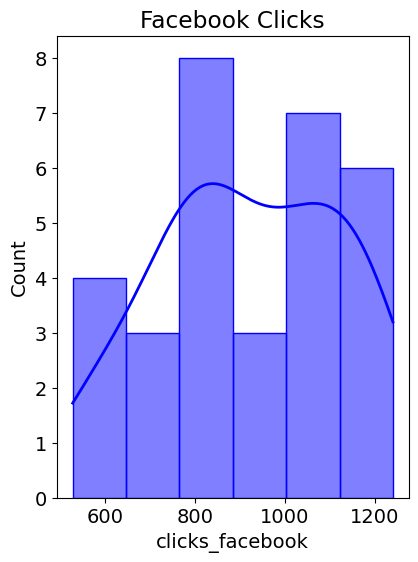

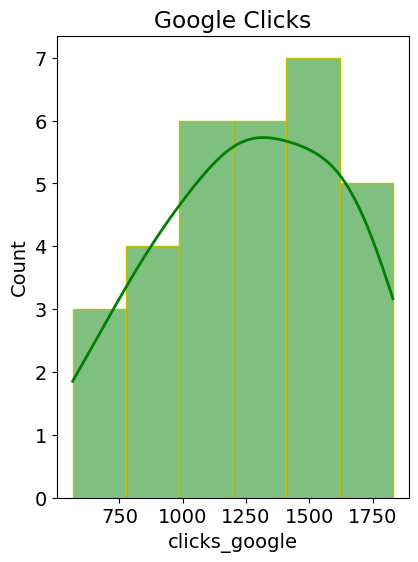

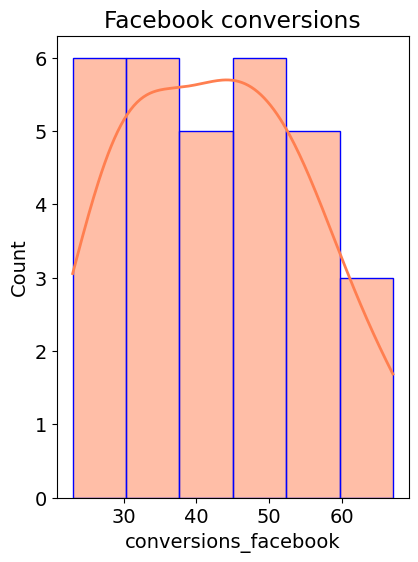

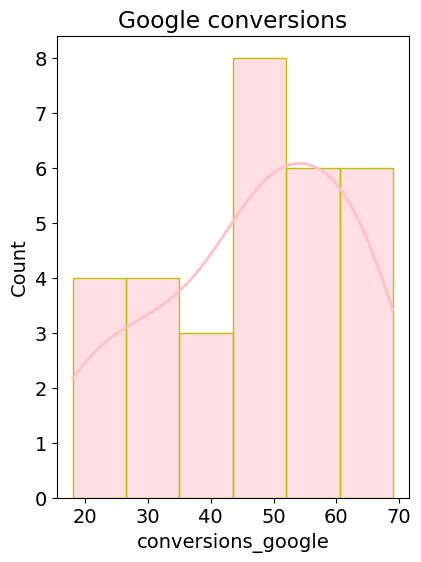

In [205]:
# distribution of the clicks and conversion

plt.subplot(1,2,1)
sns.histplot(df['clicks_facebook'],kde=True,edgecolor='b',color='blue')
plt.title('Facebook Clicks')
plt.show()

plt.subplot(1,2,2)
sns.histplot(df['clicks_google'],kde=True,edgecolor='y',color='Green')
plt.title('Google Clicks')
plt.show()

plt.subplot(1,2,1)
sns.histplot(df['conversions_facebook'],kde=True,edgecolor='b',color='coral')
plt.title('Facebook conversions')
plt.show()

plt.subplot(1,2,2)
sns.histplot(df['conversions_google'],kde=True,edgecolor='y',color='pink')
plt.title('Google conversions')
plt.show()

In [207]:
df.head()

,date,impressions_facebook,clicks_facebook,spend_facebook,conversions_facebook,ctr_facebook,cpc_facebook,cpa_facebook,conversion_rate_facebook,roas_facebook,revenue_facebook,impressions_google,clicks_google,spend_google,conversions_google,ctr_google,cpc_google,cpa_google,conversion_rate_google,roas_google,revenue_google
0,2024-01-01,53973,949,898.85,54,1.759,0.95,16.65,5.718,5.80,5211.62,35288,1175,1256.24,49,3.330,1.07,25.64,4.247,5.66,7110.29
1,2024-01-02,52513,802,511.80,45,1.528,0.64,11.37,5.673,6.76,3457.54,37928,1513,1854.98,58,3.990,1.23,31.98,3.880,3.30,6124.21
2,2024-01-03,56580,811,714.76,23,1.434,0.88,31.08,2.932,2.82,2014.12,45058,1515,1827.36,66,3.363,1.21,27.69,4.381,2.86,5218.84
3,2024-01-04,46919,749,705.37,39,1.597,0.94,18.09,5.325,4.97,3508.79,44058,1498,1768.38,65,3.401,1.18,27.21,4.380,3.20,5654.77
4,2024-01-05,52893,849,767.67,48,1.606,0.90,15.99,5.730,6.09,4671.77,28247,1249,1593.53,48,4.423,1.28,33.20,3.877,2.98,4747.37


In [213]:
# Daily Difference

df['click_diff']=df['clicks_facebook']-df['clicks_google']
df['spend_diff']=df['clicks_facebook']-df['clicks_google']
df['revenue_diff']=df['clicks_facebook']-df['clicks_google']
df['roas_diff']=df['clicks_facebook']-df['clicks_google']

In [215]:
df.columns

Index(['date', 'impressions_facebook', 'clicks_facebook', 'spend_facebook',
       'conversions_facebook', 'ctr_facebook', 'cpc_facebook', 'cpa_facebook',
       'conversion_rate_facebook', 'roas_facebook', 'revenue_facebook',
       'impressions_google', 'clicks_google', 'spend_google',
       'conversions_google', 'ctr_google', 'cpc_google', 'cpa_google',
       'conversion_rate_google', 'roas_google', 'revenue_google', 'click_diff',
       'spend_diff', 'revenue_diff', 'roas_diff'],
      dtype='object')

In [241]:
click_diff = df[['date','clicks_facebook','clicks_google','click_diff']]
click_diff.head()

,date,clicks_facebook,clicks_google,click_diff
0,2024-01-01,949,1175,-226
1,2024-01-02,802,1513,-711
2,2024-01-03,811,1515,-704
3,2024-01-04,749,1498,-749
4,2024-01-05,849,1249,-400


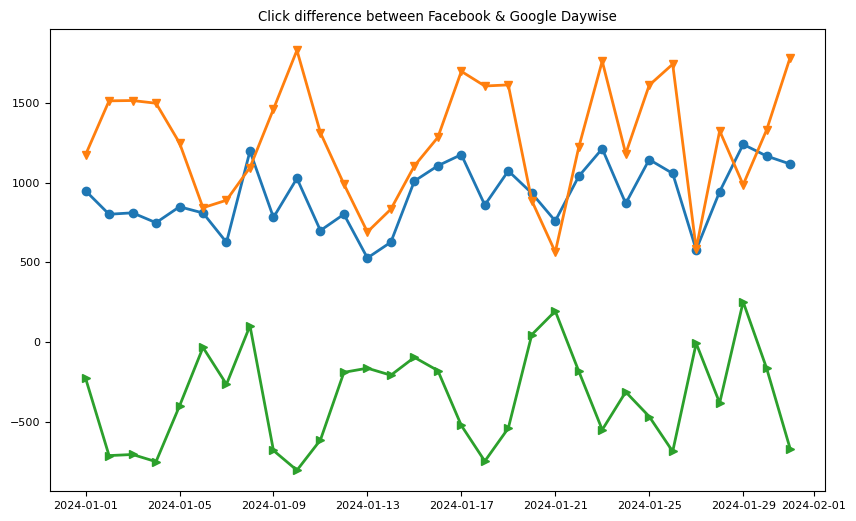

In [239]:

plt.plot(click_diff['date'], click_diff['clicks_facebook'], label='Facebook Clicks', marker='o')
plt.plot(click_diff['date'],click_diff['clicks_google'],label='Google Clicks', marker ='v')
plt.plot(click_diff['date'],click_diff['click_diff'],label='Difference Clicks', marker ='>')
plt.title('Click difference between Facebook & Google Daywise')
plt.show()


In [243]:
df.columns

Index(['date', 'impressions_facebook', 'clicks_facebook', 'spend_facebook',
       'conversions_facebook', 'ctr_facebook', 'cpc_facebook', 'cpa_facebook',
       'conversion_rate_facebook', 'roas_facebook', 'revenue_facebook',
       'impressions_google', 'clicks_google', 'spend_google',
       'conversions_google', 'ctr_google', 'cpc_google', 'cpa_google',
       'conversion_rate_google', 'roas_google', 'revenue_google', 'click_diff',
       'spend_diff', 'revenue_diff', 'roas_diff'],
      dtype='object')

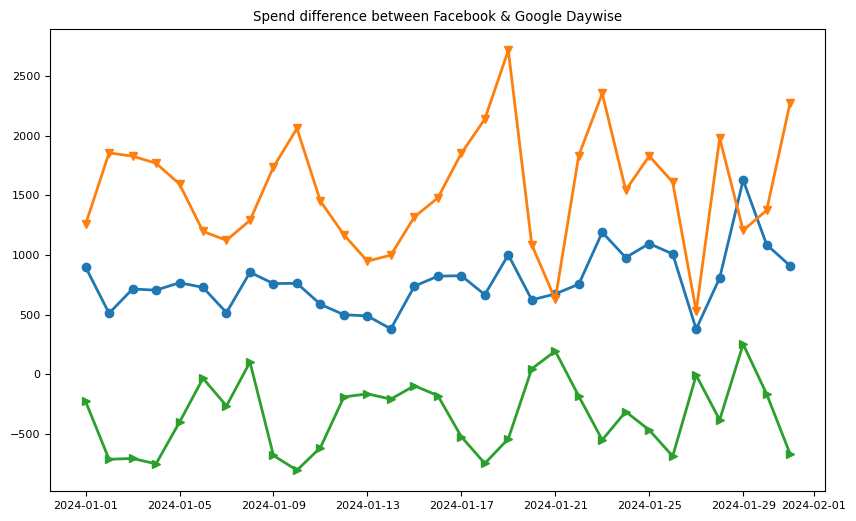

In [245]:
plt.plot(df['date'], df['spend_facebook'], label='Facebook spend', marker='o')
plt.plot(df['date'],df['spend_google'],label='Google spend', marker ='v')
plt.plot(df['date'],df['spend_diff'],label='Difference spend', marker ='>')
plt.title('Spend difference between Facebook & Google Daywise')
plt.show()


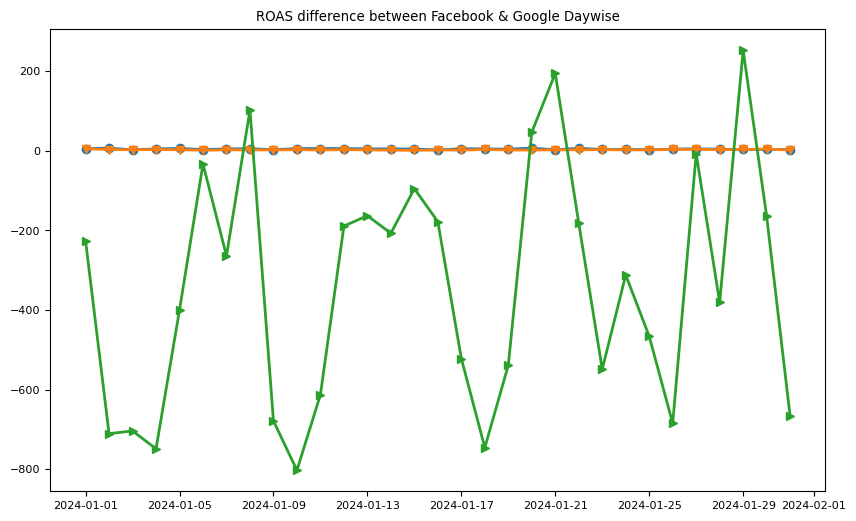

In [247]:
plt.plot(df['date'], df['roas_facebook'], label='Facebook roas', marker='o')
plt.plot(df['date'],df['roas_google'],label='Google roas', marker ='v')
plt.plot(df['date'],df['roas_diff'],label='Difference ROAS', marker ='>')
plt.title('ROAS difference between Facebook & Google Daywise')
plt.show()

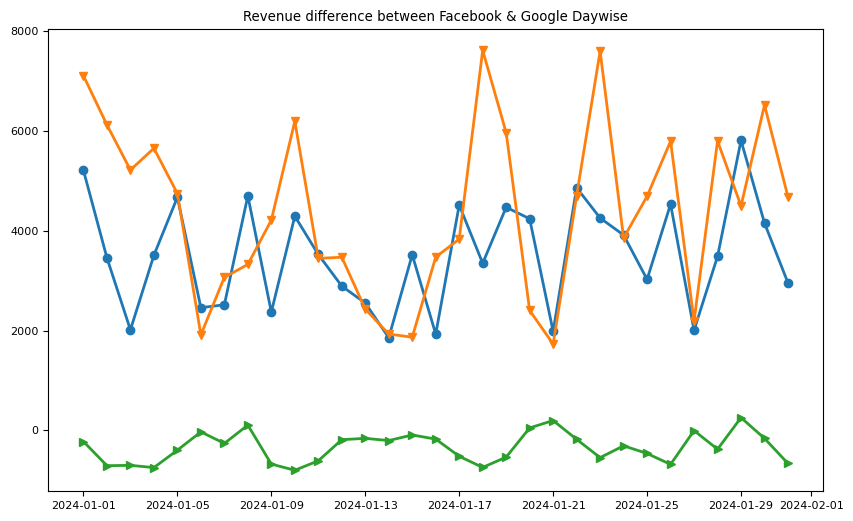

In [249]:
plt.plot(df['date'], df['revenue_facebook'], label='Facebook Revenue', marker='o')
plt.plot(df['date'],df['revenue_google'],label='Google Revenue', marker ='v')
plt.plot(df['date'],df['revenue_diff'],label='Difference ROAS', marker ='>')
plt.title('Revenue difference between Facebook & Google Daywise')
plt.show()

In [253]:
#Performance Ratios

df['facebook_advantage_roas']=df['roas_facebook']/df['roas_google']
df['facebook_advantage_cpa'] = df['cpa_google']/df['cpa_facebook']

In [257]:
df[['facebook_advantage_roas','facebook_advantage_cpa']].head()

,facebook_advantage_roas,facebook_advantage_cpa
0,1.024735,1.539940
1,2.048485,2.812665
2,0.986014,0.890927
3,1.553125,1.504146
4,2.043624,2.076298


,date,impressions,clicks,spend,conversions,ctr,cpc,cpa,conversion_rate,roas,revenue
count,31,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2024-01-16 00:00:00,52360.612903,921.064516,786.071935,42.741935,1.774710,0.845161,18.860968,4.682097,4.649677,3517.058065
min,2024-01-01 00:00:00,31292.000000,528.000000,378.860000,23.000000,1.404000,0.610000,11.370000,2.932000,2.340000,1856.760000
25%,2024-01-08 12:00:00,45474.000000,792.000000,645.595000,33.000000,1.557000,0.730000,15.195000,4.085000,3.575000,2533.670000
50%,2024-01-16 00:00:00,52513.000000,934.000000,760.130000,42.000000,1.759000,0.860000,18.000000,4.823000,4.870000,3508.790000
75%,2024-01-23 12:00:00,60420.500000,1090.000000,904.130000,52.000000,1.925500,0.935000,21.750000,5.371500,5.565000,4382.245000
max,2024-01-31 00:00:00,77309.000000,1240.000000,1626.670000,67.000000,2.389000,1.310000,31.080000,5.993000,6.800000,5811.430000
std,NaN,11244.715943,201.815086,257.154598,12.385389,0.255277,0.153967,4.960695,0.785569,1.250916,1086.328640


## Descriptive Analysis

In [261]:
#Descriptive Analysis

Facebook_Summary = facebook_df.describe()
Google_Summary = google_df.describe()

In [283]:
print(f" Facebook Summary: {round(Facebook_Summary,2)}")
print('-'*120)
print(f" Google Summary: {round(Google_Summary,2)}")

 Facebook Summary:                       date  impressions   clicks    spend  conversions    ctr  \
count                   31        31.00    31.00    31.00        31.00  31.00   
mean   2024-01-16 00:00:00     52360.61   921.06   786.07        42.74   1.77   
min    2024-01-01 00:00:00     31292.00   528.00   378.86        23.00   1.40   
25%    2024-01-08 12:00:00     45474.00   792.00   645.60        33.00   1.56   
50%    2024-01-16 00:00:00     52513.00   934.00   760.13        42.00   1.76   
75%    2024-01-23 12:00:00     60420.50  1090.00   904.13        52.00   1.93   
max    2024-01-31 00:00:00     77309.00  1240.00  1626.67        67.00   2.39   
std                    NaN     11244.72   201.82   257.15        12.39   0.26   

         cpc    cpa  conversion_rate   roas  revenue  
count  31.00  31.00            31.00  31.00    31.00  
mean    0.85  18.86             4.68   4.65  3517.06  
min     0.61  11.37             2.93   2.34  1856.76  
25%     0.73  15.20            

## Hypothesis Testing

### Test 1 ROAS Comparision

In [300]:
fb_roas = df['roas_facebook'].values
google_roas = df['roas_google'].values

In [304]:
from scipy  import stats
t_stats_roas,p_value_roas=stats.ttest_rel(fb_roas,google_roas)


In [306]:
print(f" ROAS Comparision (Paired t-test):")
print(f" Facebook avg ROAS: {fb_roas.mean():.2f}")
print(f" Google avg ROAS: {google_roas.mean():.2f}")
print(f" t-statistic: {t_stats_roas:.4f}")
print(f" p-value: {p_value_roas:.4f}")
print(f" significant? {'Yes' if p_value_roas < 0.05 else 'No'}")

 ROAS Comparision (Paired t-test):
 Facebook avg ROAS: 4.65
 Google avg ROAS: 2.87
 t-statistic: 6.9462
 p-value: 0.0000
 significant? Yes


### Test 2 : Conversion Rate Comparision

In [309]:
df.columns

Index(['date', 'impressions_facebook', 'clicks_facebook', 'spend_facebook',
       'conversions_facebook', 'ctr_facebook', 'cpc_facebook', 'cpa_facebook',
       'conversion_rate_facebook', 'roas_facebook', 'revenue_facebook',
       'impressions_google', 'clicks_google', 'spend_google',
       'conversions_google', 'ctr_google', 'cpc_google', 'cpa_google',
       'conversion_rate_google', 'roas_google', 'revenue_google', 'click_diff',
       'spend_diff', 'revenue_diff', 'roas_diff', 'facebook_advantage_roas',
       'facebook_advantage_cpa'],
      dtype='object')

In [311]:
fb_conv_rate = df['conversion_rate_facebook'].values
google_conv_rate = df['conversion_rate_google'].values

t_stats_conv,p_value_conv=stats.ttest_rel(fb_conv_rate,google_conv_rate)
print(f" Conversion Comparision (Paired t-test):")
print(f" Facebook avg rate: {fb_conv_rate.mean():.2f}")
print(f" Google avg rate: {google_conv_rate.mean():.2f}")
print(f" t-statistic: {t_stats_conv:.4f}")
print(f" p-value: {p_value_conv:.4f}")
print(f" significant? {'Yes' if p_value_conv < 0.05 else 'No'}")

 Conversion Comparision (Paired t-test):
 Facebook avg rate: 4.68
 Google avg rate: 3.73
 t-statistic: 5.0095
 p-value: 0.0000
 significant? Yes


### Test 3: CPA Comparision

In [314]:
fb_cpa = df['cpc_facebook'].values
google_cpa = df['cpa_google'].values

t_stats_cpa,p_value_cpa=stats.ttest_rel(fb_cpa,fb_cpa)
print(f" CPA Comparision (Paired t-test):")
print(f" Facebook avg cpa: {fb_cpa.mean():.2f}")
print(f" Google avg cpa: {google_cpa.mean():.2f}")
print(f" t-statistic: {t_stats_cpa:.4f}")
print(f" p-value: {p_value_cpa:.4f}")
print(f" significant? {'Yes' if p_value_cpa < 0.05 else 'No'}")

 CPA Comparision (Paired t-test):
 Facebook avg cpa: 0.85
 Google avg cpa: 34.31
 t-statistic: nan
 p-value: nan
 significant? No


## Confidence Interval

In [325]:
def calculate_ci(data,confidence=0.95):
    """calculate confidence interval"""
    n=len(data)
    mean=np.mean(data)
    std_err = stats.sem(data)
    h=std_err*stats.t.ppf((1+confidence)/2. ,n-1)
    return mean -h, mean +h

In [331]:
fb_roas_ci= calculate_ci(fb_roas)
google_roas_ci= calculate_ci(google_roas)

In [335]:
print(f" ROAS Confidence Interval:")
print(f" Facebook:[{fb_roas_ci[0]:.2f},{fb_roas_ci[1]:.2f}]")
print(f" Google:[{google_roas_ci[0]:.2f},{google_roas_ci[1]:.2f}]")

 ROAS Confidence Interval:
 Facebook:[4.19,5.11]
 Google:[2.54,3.19]


In [339]:
fb_cpa_ci= calculate_ci(fb_cpa)
google_cpa_ci= calculate_ci(google_cpa)

print(f" CPA Confidence Interval:")
print(f" Facebook:[{fb_cpa_ci[0]:.2f},{fb_cpa_ci[1]:.2f}]")
print(f" Google:[{google_cpa_ci[0]:.2f},{google_cpa_ci[1]:.2f}]")


 CPA Confidence Interval:
 Facebook:[0.79,0.90]
 Google:[31.01,37.61]


### PERFORMANCE SUMMARY

In [342]:
df.columns

Index(['date', 'impressions_facebook', 'clicks_facebook', 'spend_facebook',
       'conversions_facebook', 'ctr_facebook', 'cpc_facebook', 'cpa_facebook',
       'conversion_rate_facebook', 'roas_facebook', 'revenue_facebook',
       'impressions_google', 'clicks_google', 'spend_google',
       'conversions_google', 'ctr_google', 'cpc_google', 'cpa_google',
       'conversion_rate_google', 'roas_google', 'revenue_google', 'click_diff',
       'spend_diff', 'revenue_diff', 'roas_diff', 'facebook_advantage_roas',
       'facebook_advantage_cpa'],
      dtype='object')

In [346]:
fb_total_spend = df['spend_facebook'].sum()
google_total_spend = df['spend_google'].sum()
fb_total_revenue = df['revenue_facebook'].sum()
google_total_revenue = df['revenue_google'].sum()
fb_total_conversion = df['conversions_facebook'].sum()
google_total_conversion = df['conversions_google'].sum()

In [348]:
print("CAMPAIGN TOTALS:")
print(f"Facebook - Spend: ${fb_total_spend:,.2f} | Revenue: ${fb_total_revenue:,.2f} | ROAS: {fb_total_revenue/fb_total_spend:.2f}")
print(f"Google   - Spend: ${google_total_spend:,.2f} | Revenue: ${google_total_revenue:,.2f} | ROAS: {google_total_revenue/google_total_spend:.2f}")

CAMPAIGN TOTALS:
Facebook - Spend: $24,368.23 | Revenue: $109,028.80 | ROAS: 4.47
Google   - Spend: $48,013.67 | Revenue: $136,076.86 | ROAS: 2.83


In [352]:
print(f"\nCONVERSIONS:")
print(f"Facebook: {fb_total_conversion:,} conversions")
print(f"Google:   {google_total_conversion:,} conversions")


CONVERSIONS:
Facebook: 1,325 conversions
Google:   1,450 conversions


In [354]:
# winner logic
facebook_wins = 0
google_wins = 0

In [358]:
#ROAS Winner

if fb_total_revenue/fb_total_spend > google_total_revenue/google_total_spend:
    facebook_wins +=1
    roas_winner = 'Facebook'
else:
    google_wins +=1
    roas_winner ='Google'

print(f" ROAS Winner: {roas_winner}")

 ROAS Winner: Facebook


In [360]:
# CPA Winner

if fb_cpa.mean() < google_cpa.mean():
    facebook_wins +=1
    cpa_winner = 'Facebook'
else:
    google_wins +=1
    cpa_winner ='Google'

print(f" CPA Winner: {cpa_winner}")

 CPA Winner: Facebook


In [362]:
# Conversion Rate Winner


if fb_conv_rate.mean() < google_conv_rate.mean():
    facebook_wins +=1
    conv_rate_winner = 'Facebook'
else:
    google_wins +=1
    conv_rate_winner ='Google'

print(f" Conv_rate Winner: {conv_rate_winner}")

 Conv_rate Winner: Google


In [364]:
overall_winner = "Facebook" if facebook_wins > google_wins else "Google"
print(f"\n🏆 OVERALL WINNER: {overall_winner}")


🏆 OVERALL WINNER: Facebook


In [366]:
# STEP 10: RECOMMENDATIONS

if overall_winner == "Facebook":
    winner_roas = fb_total_revenue/fb_total_spend
    winner_cpa = fb_cpa.mean()
    recommended_split = "70% Facebook, 30% Google"
else:
    winner_roas = google_total_revenue/google_total_spend
    winner_cpa = google_cpa.mean()
    recommended_split = "70% Google, 30% Facebook"

print(f"✅ Primary Platform: {overall_winner}")
print(f"✅ Winner ROAS: {winner_roas:.2f}")
print(f"✅ Winner CPA: ${winner_cpa:.2f}")
print(f"✅ Recommended Budget Split: {recommended_split}")

✅ Primary Platform: Facebook
✅ Winner ROAS: 4.47
✅ Winner CPA: $0.85
✅ Recommended Budget Split: 70% Facebook, 30% Google


In [368]:
# Success criteria check
print(f"\n📋 SUCCESS CRITERIA CHECK:")
print(f"✅ ROAS > 3.0: {'PASS' if winner_roas > 3.0 else 'FAIL'} ({winner_roas:.2f})")
print(f"✅ CPA < $30: {'PASS' if winner_cpa < 30 else 'FAIL'} (${winner_cpa:.2f})")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE! 🎉")
print("=" * 60)


📋 SUCCESS CRITERIA CHECK:
✅ ROAS > 3.0: PASS (4.47)
✅ CPA < $30: PASS ($0.85)

ANALYSIS COMPLETE! 🎉


In [372]:
results_df = df[['date', 'clicks_facebook', 'clicks_google', 'spend_facebook', 
                       'spend_google', 'conversions_facebook', 'conversions_google',
                       'roas_facebook', 'roas_google', 'cpa_facebook', 'cpa_google']]

results_df.to_csv('ab_test_results.csv', index=False)
print("📁 Results saved to 'ab_test_results.csv'")

📁 Results saved to 'ab_test_results.csv'
